In [1]:
print("HealthClaim AI is ready!")

HealthClaim AI is ready!


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "claim_id": [f"C{str(i).zfill(5)}" for i in range(1, n + 1)],
    "patient_age": np.random.randint(18, 81, n),
    "claim_amount": np.random.randint(5000, 150001, n),
    "previous_claims": np.random.randint(0, 11, n),
    "previous_rejections": np.random.randint(0, 5, n),
    "missing_documents": np.random.choice(["Yes", "No"], n),
    "provider_risk": np.random.choice(["Low", "Medium", "High"], n),
    "diagnosis": np.random.choice(
        ["Cardiac", "Orthopedic", "Respiratory", "Diabetes", "General"],
        n
    ),
    "procedure": np.random.choice(
        ["Surgery", "Consultation", "Diagnostic", "Therapy", "Hospitalization"],
        n
    )
}

df = pd.DataFrame(data)

df.head()

,claim_id,patient_age,claim_amount,previous_claims,previous_rejections,missing_documents,provider_risk,diagnosis,procedure
0,C00001,56,55990,7,2,Yes,Medium,Diabetes,Surgery
1,C00002,69,134473,5,4,Yes,Low,Cardiac,Hospitalization
2,C00003,46,63141,10,0,No,Medium,General,Diagnostic
3,C00004,32,61570,3,2,Yes,High,Orthopedic,Hospitalization
4,C00005,60,6015,1,0,No,High,Diabetes,Surgery


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   claim_id             1000 non-null   str  
 1   patient_age          1000 non-null   int32
 2   claim_amount         1000 non-null   int32
 3   previous_claims      1000 non-null   int32
 4   previous_rejections  1000 non-null   int32
 5   missing_documents    1000 non-null   str  
 6   provider_risk        1000 non-null   str  
 7   diagnosis            1000 non-null   str  
 8   procedure            1000 non-null   str  
dtypes: int32(4), str(5)
memory usage: 54.8 KB


In [6]:
df.describe()

,patient_age,claim_amount,previous_claims,previous_rejections
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.380000,79302.632000,4.889000,2.040000
std,18.378666,42176.987194,3.068566,1.422119
min,18.000000,5126.000000,0.000000,0.000000
25%,35.000000,43691.250000,2.000000,1.000000
50%,50.000000,79013.500000,5.000000,2.000000
75%,66.000000,116617.750000,8.000000,3.000000
max,80.000000,149991.000000,10.000000,4.000000


In [7]:
# Calculate a risk score for each claim

risk_score = (
    0.00001 * df["claim_amount"]
    + 0.30 * df["previous_rejections"]
    + 0.40 * (df["missing_documents"] == "Yes")
    + 0.50 * (df["provider_risk"] == "High")
    + 0.20 * (df["provider_risk"] == "Medium")
)

# Convert risk score into probability
probability = 1 / (1 + np.exp(-risk_score + 2.5))

# Generate the target variable
df["manual_review"] = np.random.binomial(1, probability)

df.head()

,claim_id,patient_age,claim_amount,previous_claims,previous_rejections,missing_documents,provider_risk,diagnosis,procedure,manual_review
0,C00001,56,55990,7,2,Yes,Medium,Diabetes,Surgery,0
1,C00002,69,134473,5,4,Yes,Low,Cardiac,Hospitalization,1
2,C00003,46,63141,10,0,No,Medium,General,Diagnostic,0
3,C00004,32,61570,3,2,Yes,High,Orthopedic,Hospitalization,1
4,C00005,60,6015,1,0,No,High,Diabetes,Surgery,0


In [8]:
df["manual_review"].value_counts()

manual_review
0    660
1    340
Name: count, dtype: int64

In [9]:
df["manual_review"].value_counts(normalize=True)

manual_review
0    0.66
1    0.34
Name: proportion, dtype: float64

In [10]:
df.to_csv("../data/raw/healthcare_claims.csv", index=False)

In [11]:
pd.crosstab(
    df["missing_documents"],
    df["manual_review"],
    normalize="index"
)

manual_review,0,1
missing_documents,,
No,0.708678,0.291322
Yes,0.614341,0.385659


In [12]:
pd.crosstab(
    df["provider_risk"],
    df["manual_review"],
    normalize="index"
)

manual_review,0,1
provider_risk,,
High,0.566667,0.433333
Low,0.734628,0.265372
Medium,0.691843,0.308157


In [13]:
df.groupby("manual_review")["claim_amount"].mean()

manual_review
0    74598.266667
1    88434.635294
Name: claim_amount, dtype: float64

In [14]:
pd.crosstab(
    df["previous_rejections"],
    df["manual_review"],
    normalize="index"
)

manual_review,0,1
previous_rejections,,
0,0.809756,0.190244
1,0.690058,0.309942
2,0.673077,0.326923
3,0.578199,0.421801
4,0.556098,0.443902


In [15]:
df.shape

(1000, 10)

In [16]:
df.columns

Index(['claim_id', 'patient_age', 'claim_amount', 'previous_claims',
       'previous_rejections', 'missing_documents', 'provider_risk',
       'diagnosis', 'procedure', 'manual_review'],
      dtype='str')

In [17]:
X = df.drop(columns=["claim_id", "manual_review"])
y = df["manual_review"]

In [18]:
X.head()

,patient_age,claim_amount,previous_claims,previous_rejections,missing_documents,provider_risk,diagnosis,procedure
0,56,55990,7,2,Yes,Medium,Diabetes,Surgery
1,69,134473,5,4,Yes,Low,Cardiac,Hospitalization
2,46,63141,10,0,No,Medium,General,Diagnostic
3,32,61570,3,2,Yes,High,Orthopedic,Hospitalization
4,60,6015,1,0,No,High,Diabetes,Surgery


In [19]:
y.head()

0    0
1    1
2    0
3    1
4    0
Name: manual_review, dtype: int32

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "patient_age",
    "claim_amount",
    "previous_claims",
    "previous_rejections"
]

categorical_features = [
    "missing_documents",
    "provider_risk",
    "diagnosis",
    "procedure"
]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 8)
X_test : (200, 8)
y_train: (800,)
y_test : (200,)


In [ ]:
#categorical values to numerical values through one hot encoding
X_train_processed = preprocessor.fit_transform(X_train)
#already learned the categories from X_train 
X_test_processed = preprocessor.transform(X_test)

In [25]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (800, 19)
Processed X_test shape: (200, 19)


In [26]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFeature names:")
for feature in feature_names:
    print(feature)

Number of features: 19

Feature names:
num__patient_age
num__claim_amount
num__previous_claims
num__previous_rejections
cat__missing_documents_No
cat__missing_documents_Yes
cat__provider_risk_High
cat__provider_risk_Low
cat__provider_risk_Medium
cat__diagnosis_Cardiac
cat__diagnosis_Diabetes
cat__diagnosis_General
cat__diagnosis_Orthopedic
cat__diagnosis_Respiratory
cat__procedure_Consultation
cat__procedure_Diagnostic
cat__procedure_Hospitalization
cat__procedure_Surgery
cat__procedure_Therapy


In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
model = LogisticRegression(max_iter=1000)

In [29]:
model.fit(X_train_processed, y_train)

c:\Users\bhuva\OneDrive\Documents\Desktop\HealthClaim-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [33]:
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (800, 19)
X_test_processed shape: (200, 19)


In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
model = LogisticRegression(max_iter=1000)

In [36]:
model.fit(X_train_processed, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [37]:
y_pred = model.predict(X_test_processed)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.65


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[108  24]
 [ 46  22]]


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.82      0.76       132
           1       0.48      0.32      0.39        68

    accuracy                           0.65       200
   macro avg       0.59      0.57      0.57       200
weighted avg       0.63      0.65      0.63       200



In [ ]:
#model is not fit for our project
#lets improve

In [41]:
model_balanced = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

In [42]:
model_balanced.fit(X_train_processed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [43]:
y_pred_balanced = model_balanced.predict(X_test_processed)

print(y_pred_balanced[:10])

[0 0 1 1 0 0 1 0 0 0]


In [44]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(cm_balanced)

Confusion Matrix:
[[76 56]
 [20 48]]


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.79      0.58      0.67       132
           1       0.46      0.71      0.56        68

    accuracy                           0.62       200
   macro avg       0.63      0.64      0.61       200
weighted avg       0.68      0.62      0.63       200



In [46]:
y_prob = model_balanced.predict_proba(X_test_processed)[:, 1]

print(y_prob[:10])

[0.27975437 0.36509039 0.64279322 0.63127503 0.22070654 0.32311613
 0.59809368 0.27408232 0.32770803 0.48926653]


In [47]:
threshold = 0.40

y_pred_threshold = (y_prob >= threshold).astype(int)

print(y_pred_threshold[:10])

[0 0 1 1 0 0 1 0 0 1]


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))

Confusion Matrix:
[[59 73]
 [13 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.45      0.58       132
           1       0.43      0.81      0.56        68

    accuracy                           0.57       200
   macro avg       0.62      0.63      0.57       200
weighted avg       0.69      0.57      0.57       200



In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.2f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.2f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.2f}"
    )

Threshold: 0.30 | Accuracy: 0.49 | Precision: 0.39 | Recall: 0.93 | F1: 0.55
Threshold: 0.35 | Accuracy: 0.55 | Precision: 0.42 | Recall: 0.88 | F1: 0.57
Threshold: 0.40 | Accuracy: 0.57 | Precision: 0.43 | Recall: 0.81 | F1: 0.56
Threshold: 0.45 | Accuracy: 0.59 | Precision: 0.44 | Recall: 0.78 | F1: 0.56
Threshold: 0.50 | Accuracy: 0.62 | Precision: 0.46 | Recall: 0.71 | F1: 0.56
Threshold: 0.55 | Accuracy: 0.61 | Precision: 0.45 | Recall: 0.59 | F1: 0.51
Threshold: 0.60 | Accuracy: 0.60 | Precision: 0.42 | Recall: 0.44 | F1: 0.43


In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_balanced)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Sensitivity (Recall): 0.7058823529411765
Specificity: 0.5757575757575758


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities for class 1
y_prob = model.predict_proba(X_test_processed)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.6564171122994653


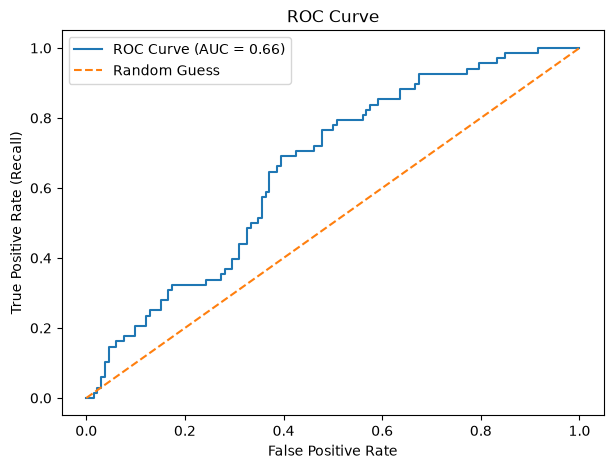

In [52]:
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [54]:
y_pred_rf = rf_model.predict(X_test_processed)

print(y_pred_rf[:10])

[0 0 0 1 0 0 0 0 0 0]


In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.66

Confusion Matrix:
[[115  17]
 [ 51  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.87      0.77       132
           1       0.50      0.25      0.33        68

    accuracy                           0.66       200
   macro avg       0.60      0.56      0.55       200
weighted avg       0.63      0.66      0.62       200



In [57]:
# Get probability of class 1
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print(y_prob_rf[:10])

[0.18 0.39 0.37 0.6  0.37 0.11 0.47 0.16 0.13 0.29]


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold_rf = (y_prob_rf >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy_score(y_test, y_pred_threshold_rf):.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold_rf):.2f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold_rf):.2f} | "
        f"F1: {f1_score(y_test, y_pred_threshold_rf):.2f}"
    )

Threshold: 0.30 | Accuracy: 0.56 | Precision: 0.42 | Recall: 0.71 | F1: 0.52
Threshold: 0.35 | Accuracy: 0.61 | Precision: 0.45 | Recall: 0.62 | F1: 0.52
Threshold: 0.40 | Accuracy: 0.67 | Precision: 0.51 | Recall: 0.54 | F1: 0.52
Threshold: 0.45 | Accuracy: 0.69 | Precision: 0.54 | Recall: 0.46 | F1: 0.50
Threshold: 0.50 | Accuracy: 0.65 | Precision: 0.46 | Recall: 0.25 | F1: 0.32
Threshold: 0.55 | Accuracy: 0.65 | Precision: 0.45 | Recall: 0.19 | F1: 0.27
Threshold: 0.60 | Accuracy: 0.65 | Precision: 0.46 | Recall: 0.16 | F1: 0.24


In [59]:
best_threshold_rf = 0.40

y_pred_rf_threshold = (y_prob_rf >= best_threshold_rf).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_threshold))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_threshold))

Confusion Matrix:
[[96 36]
 [31 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       132
           1       0.51      0.54      0.52        68

    accuracy                           0.67       200
   macro avg       0.63      0.64      0.63       200
weighted avg       0.67      0.67      0.67       200



In [60]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf_threshold)

tn, fp, fn, tp = cm_rf.ravel()

sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)

print("Sensitivity (Recall):", sensitivity_rf)
print("Specificity:", specificity_rf)

Sensitivity (Recall): 0.5441176470588235
Specificity: 0.7272727272727273


In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities for class 1
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

# Calculate ROC values
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.6439950980392157


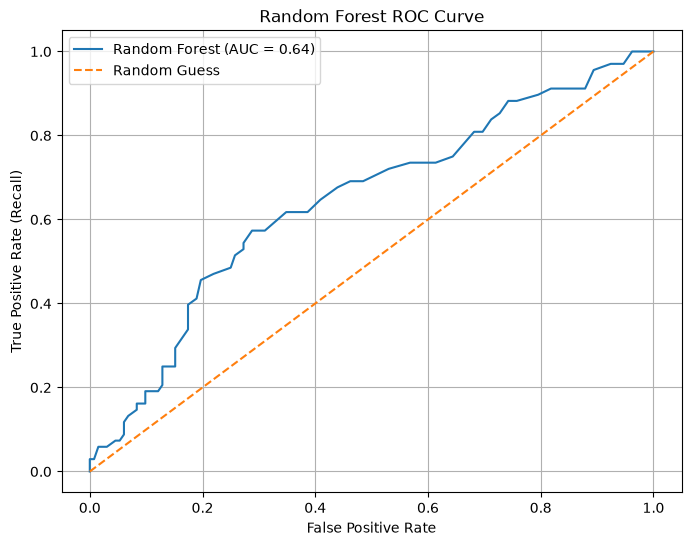

In [62]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid()

plt.show()

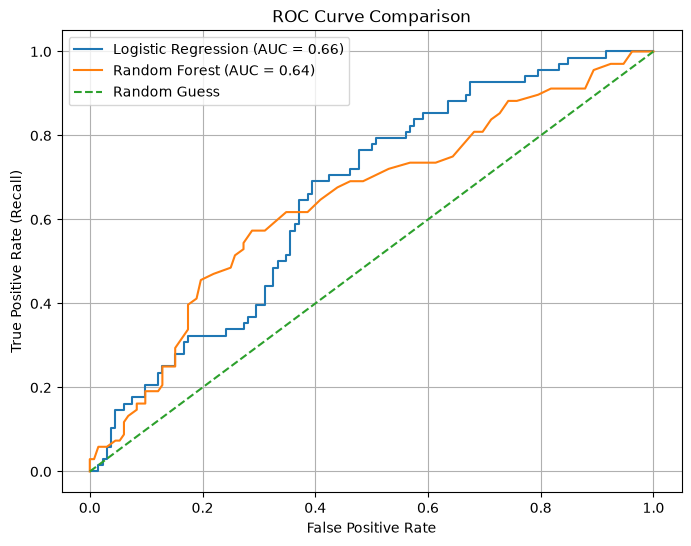

In [63]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')

plt.legend()
plt.grid()

plt.show()

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression predictions at threshold 0.50
best_threshold_lr = 0.50

y_pred_lr_final = (y_prob >= best_threshold_lr).astype(int)

print("Logistic Regression - Threshold 0.50")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_final))
print("Precision:", precision_score(y_test, y_pred_lr_final))
print("Recall   :", recall_score(y_test, y_pred_lr_final))
print("F1 Score :", f1_score(y_test, y_pred_lr_final))

Logistic Regression - Threshold 0.50
Accuracy : 0.65
Precision: 0.4782608695652174
Recall   : 0.3235294117647059
F1 Score : 0.38596491228070173


In [65]:
best_threshold_lr = 0.35

y_pred_lr_best = (y_prob >= best_threshold_lr).astype(int)

print("Logistic Regression - Best Threshold:", best_threshold_lr)
print("Accuracy :", accuracy_score(y_test, y_pred_lr_best))
print("Precision:", precision_score(y_test, y_pred_lr_best))
print("Recall   :", recall_score(y_test, y_pred_lr_best))
print("F1 Score :", f1_score(y_test, y_pred_lr_best))

Logistic Regression - Best Threshold: 0.35
Accuracy : 0.625
Precision: 0.46534653465346537
Recall   : 0.6911764705882353
F1 Score : 0.5562130177514792


In [67]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(
    model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='f1'
)

rf_scores = cross_val_score(
    rf_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='f1'
)

print("Logistic Regression F1 CV scores:", lr_scores)
print("Logistic Regression Mean F1:", lr_scores.mean())

print("\nRandom Forest F1 CV scores:", rf_scores)
print("Random Forest Mean F1:", rf_scores.mean())

Logistic Regression F1 CV scores: [0.325      0.375      0.4691358  0.35       0.42352941]
Logistic Regression Mean F1: 0.3885330428467684

Random Forest F1 CV scores: [0.30379747 0.37037037 0.21917808 0.425      0.36363636]
Random Forest Mean F1: 0.33639645691058906


In [68]:
lr_auc_scores = cross_val_score(
    model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='roc_auc'
)

rf_auc_scores = cross_val_score(
    rf_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Logistic Regression AUC CV scores:", lr_auc_scores)
print("Logistic Regression Mean AUC:", lr_auc_scores.mean())

print("\nRandom Forest AUC CV scores:", rf_auc_scores)
print("Random Forest Mean AUC:", rf_auc_scores.mean())

Logistic Regression AUC CV scores: [0.68813853 0.67878788 0.65531097 0.66107617 0.69933613]
Logistic Regression Mean AUC: 0.6765299354733316

Random Forest AUC CV scores: [0.6178355  0.6369697  0.6165269  0.64570231 0.62971698]
Random Forest Mean AUC: 0.6293502772559376


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# Final threshold
best_threshold_lr = 0.35

# Convert probabilities into final predictions
y_pred_lr_final = (y_prob >= best_threshold_lr).astype(int)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_final)

tn, fp, fn, tp = cm_lr.ravel()

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr_final)
precision_lr = precision_score(y_test, y_pred_lr_final)
recall_lr = recall_score(y_test, y_pred_lr_final)
f1_lr = f1_score(y_test, y_pred_lr_final)
specificity_lr = tn / (tn + fp)

# AUC uses probabilities, NOT threshold predictions
auc_lr = roc_auc_score(y_test, y_prob)

print("FINAL LOGISTIC REGRESSION RESULTS")
print("----------------------------------")
print("Threshold:", best_threshold_lr)
print("Accuracy:", round(accuracy_lr, 3))
print("Precision:", round(precision_lr, 3))
print("Recall (Sensitivity):", round(recall_lr, 3))
print("Specificity:", round(specificity_lr, 3))
print("F1 Score:", round(f1_lr, 3))
print("ROC-AUC:", round(auc_lr, 3))

print("\nConfusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_final))

FINAL LOGISTIC REGRESSION RESULTS
----------------------------------
Threshold: 0.35
Accuracy: 0.625
Precision: 0.465
Recall (Sensitivity): 0.691
Specificity: 0.591
F1 Score: 0.556
ROC-AUC: 0.656

Confusion Matrix:
[[78 54]
 [21 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.59      0.68       132
           1       0.47      0.69      0.56        68

    accuracy                           0.62       200
   macro avg       0.63      0.64      0.62       200
weighted avg       0.68      0.62      0.63       200



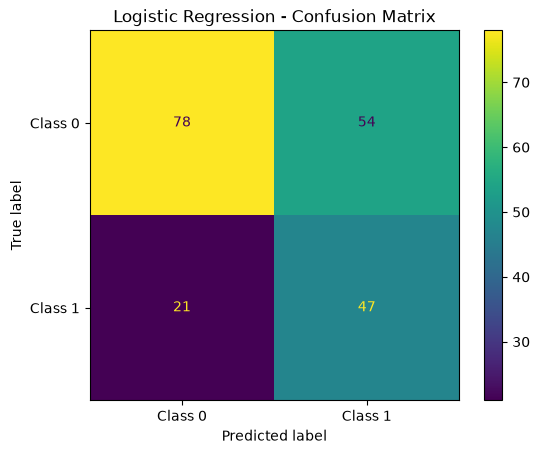

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

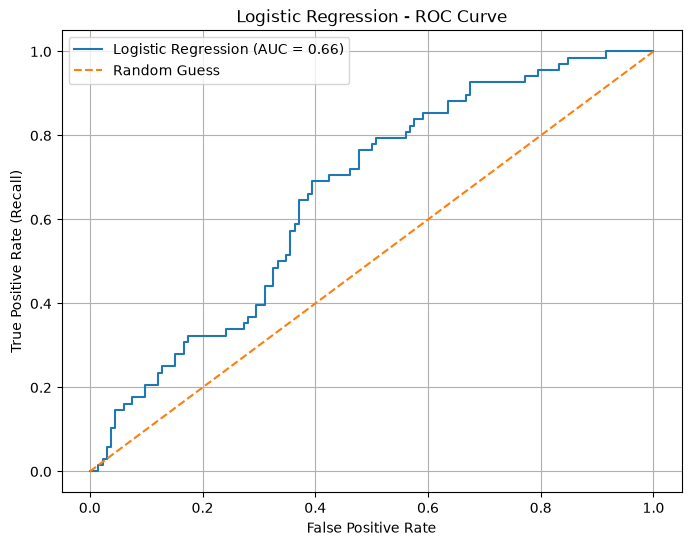

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob)

# AUC
auc_lr = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [72]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

specificity_rf = tn_rf / (tn_rf + fp_rf)

print("Random Forest Specificity:", round(specificity_rf, 3))

Random Forest Specificity: 0.871


In [74]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "Specificity",
        "F1 Score",
        "Test AUC",
        "CV Mean F1",
        "CV Mean AUC"
    ],

    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        specificity_lr,
        f1_lr,
        auc_lr,
        lr_scores.mean(),
        lr_auc_scores.mean()
    ],

    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        specificity_rf,
        f1_score(y_test, y_pred_rf),
        auc_rf,
        rf_scores.mean(),
        rf_auc_scores.mean()
    ]
})

print(comparison.round(3))

                 Metric  Logistic Regression  Random Forest
0              Accuracy                0.625          0.660
1             Precision                0.465          0.500
2  Recall (Sensitivity)                0.691          0.250
3           Specificity                0.591          0.871
4              F1 Score                0.556          0.333
5              Test AUC                0.656          0.644
6            CV Mean F1                0.389          0.336
7           CV Mean AUC                0.677          0.629


In [75]:
# Random Forest predictions using its selected threshold
best_threshold_rf = 0.40

y_pred_rf_final = (y_prob_rf >= best_threshold_rf).astype(int)

cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf_final.ravel()

accuracy_rf_final = accuracy_score(y_test, y_pred_rf_final)
precision_rf_final = precision_score(y_test, y_pred_rf_final)
recall_rf_final = recall_score(y_test, y_pred_rf_final)
specificity_rf_final = tn_rf / (tn_rf + fp_rf)
f1_rf_final = f1_score(y_test, y_pred_rf_final)

print("RANDOM FOREST - FINAL THRESHOLD 0.40")
print("------------------------------------")
print("Accuracy:", round(accuracy_rf_final, 3))
print("Precision:", round(precision_rf_final, 3))
print("Recall:", round(recall_rf_final, 3))
print("Specificity:", round(specificity_rf_final, 3))
print("F1 Score:", round(f1_rf_final, 3))

print("\nConfusion Matrix:")
print(cm_rf_final)

RANDOM FOREST - FINAL THRESHOLD 0.40
------------------------------------
Accuracy: 0.665
Precision: 0.507
Recall: 0.544
Specificity: 0.727
F1 Score: 0.525

Confusion Matrix:
[[96 36]
 [31 37]]


In [77]:
# Final Model Selection

final_model = model
final_threshold = best_threshold_lr

# Calculate Logistic Regression specificity
cm_lr_final = confusion_matrix(y_test, y_pred_lr_best)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr_final.ravel()

specificity_lr_final = tn_lr / (tn_lr + fp_lr)

print("FINAL MODEL")
print("=" * 40)
print("Model: Logistic Regression")
print("Threshold:", final_threshold)
print("CV Mean AUC:", round(lr_auc_scores.mean(), 3))
print("CV Mean F1:", round(lr_scores.mean(), 3))
print("Test AUC:", round(auc_lr, 3))
print("Test F1:", round(f1_score(y_test, y_pred_lr_best), 3))
print("Test Recall:", round(recall_score(y_test, y_pred_lr_best), 3))
print("Test Specificity:", round(specificity_lr_final, 3))

FINAL MODEL
Model: Logistic Regression
Threshold: 0.35
CV Mean AUC: 0.677
CV Mean F1: 0.389
Test AUC: 0.656
Test F1: 0.556
Test Recall: 0.691
Test Specificity: 0.591


In [83]:
print("Original x_train shape:", X_train.shape)
print("Processed x_train shape:", X_train_processed.shape)
print("Number of model coefficients:", len(model.coef_[0]))
print("Original feature names:", len(X_train.columns))

Original x_train shape: (800, 8)
Processed x_train shape: (800, 19)
Number of model coefficients: 19
Original feature names: 8


In [84]:
# Get feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 19
['num__patient_age' 'num__claim_amount' 'num__previous_claims'
 'num__previous_rejections' 'cat__missing_documents_No'
 'cat__missing_documents_Yes' 'cat__provider_risk_High'
 'cat__provider_risk_Low' 'cat__provider_risk_Medium'
 'cat__diagnosis_Cardiac' 'cat__diagnosis_Diabetes'
 'cat__diagnosis_General' 'cat__diagnosis_Orthopedic'
 'cat__diagnosis_Respiratory' 'cat__procedure_Consultation'
 'cat__procedure_Diagnostic' 'cat__procedure_Hospitalization'
 'cat__procedure_Surgery' 'cat__procedure_Therapy']


In [85]:
import pandas as pd
import numpy as np

# Get Logistic Regression coefficients
coefficients = model.coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

print("Top Features:")
print(feature_importance.head(10))

Top Features:
                        Feature  Coefficient  Absolute Importance
3      num__previous_rejections     0.453846             0.453846
6       cat__provider_risk_High     0.438149             0.438149
1             num__claim_amount     0.389594             0.389594
7        cat__provider_risk_Low    -0.310722             0.310722
17       cat__procedure_Surgery    -0.275448             0.275448
5    cat__missing_documents_Yes     0.248358             0.248358
4     cat__missing_documents_No    -0.239620             0.239620
9        cat__diagnosis_Cardiac    -0.223662             0.223662
13   cat__diagnosis_Respiratory     0.201474             0.201474
14  cat__procedure_Consultation     0.142291             0.142291


In [86]:
print(type(model))
print(type(preprocessor))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [91]:
from sklearn.pipeline import Pipeline
import joblib

# Combine preprocessing + Logistic Regression
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# Save the complete pipeline
joblib.dump(model_pipeline, "healthclaim_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [88]:
model_pipeline_loaded = joblib.load("healthclaim_model.pkl")

print("Model loaded successfully!")
print(model_pipeline_loaded)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['patient_age',
                                                   'claim_amount',
                                                   'previous_claims',
                                                   'previous_rejections']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['missing_documents',
                                                   'provider_risk', 'diagnosis',
                                                   'procedure'])])),
                ('model', LogisticRegression(max_iter=1000))])


In [92]:
import joblib

joblib.dump(model_pipeline, "../models/healthclaim_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [93]:
print("Class labels:", model.classes_)
print("Class 0 probability:", y_prob[0])
print("Class 1 probability:", 1 - y_prob[0])

Class labels: [0 1]
Class 0 probability: 0.15997297849861083
Class 1 probability: 0.8400270215013892


In [94]:
sample_probability = y_prob[0]

print("Probability of Class 0:", 1 - sample_probability)
print("Probability of Class 1:", sample_probability)

if sample_probability >= 0.35:
    print("Prediction: Class 1")
else:
    print("Prediction: Class 0")

Probability of Class 0: 0.8400270215013892
Probability of Class 1: 0.15997297849861083
Prediction: Class 0


In [96]:
# Check important variables available in the notebook

print("Model:", type(model))
print("Processed training data:", type(X_train_processed))
print("Processed test data:", type(X_test_processed))

print("\nAvailable preprocessing-related variables:")
for name in dir():
    if any(word in name.lower() for word in ["preprocess", "transform", "scaler", "encoder"]):
        print(name)

Model: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Processed training data: <class 'numpy.ndarray'>
Processed test data: <class 'numpy.ndarray'>

Available preprocessing-related variables:
ColumnTransformer
OneHotEncoder
StandardScaler
preprocessor


In [97]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [98]:

import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [99]:
import os

print("Model exists:", os.path.exists("logistic_regression_model.pkl"))
print("Preprocessor exists:", os.path.exists("preprocessor.pkl"))

Model exists: True
Preprocessor exists: True
